# 10. Sigmoid Function

This notebook explains the sigmoid function, which is the core function used is logistic regression.

이 노트북에서는 logistic regression의 핵심 함수인 sigmoid function을 학습한다.

The sigmoid funcion converts any real-valued number into a value between 0 and 1.

sigmoid 함수는 어떤 실수값이 들어와도 0과 1사이의 값으로 변환해준다.

This is why it is useful for binary classification.

이 때문에 binary classification에서 확률처럼 사용할 수 있어 유용하다.

## 1. Why do we need the sigmoid function?

Linear regression can output any real number:
- negative values
- values larger than 1
- any number on the real time

선형 회귀(linear regression)는 어떤 실수값이든 출력할 수 있다.  
예를 들어 음수나 1보다 큰 값도 나올 수 있다.

However, in binary classification we want an output that can be interpreted as a probability.

하지만 binary classification에서는  
출력을 확률처럼 해석할 수 있어야 한다.

So we need a function that maps any number to the range 0 to 1.

따라서 어떤 숫자든 0과 1 사이로 바꿔주는 함수가 필요하다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Definition of the sigmoid functon

The sigmoid function is defined as:

g(z) = 1 / (1 + e^(-z))

sigmoid 함수는 다음과 같이 정의된다:

g(z) = 1 / (1 + e^(-z))

Here:
- z is the input
- e is Euler's number (approximately 2.718)

여기서:
- z는 입력값
- e는 자연상수(약 2.718)이다

In [ ]:
def sigmoid(z):
    """
    Compute the sigmoid of z.

    z가 어떤 값이든 0과 1 사이로 변환한다.
    """
    # np.exp(-z)는 e^(-z)를 계산
    # 전체 식: 1 / (1 + e^(-z))
    return 1 / (1 + np.exp(-z))

## 3. Check several input values

Let's see what happens when we imput different values into the sigmoid function.

여러 입력값을 sigmoid 함수에 넣었을 때  
출력이 어떻게 바뀌는지 확인해보자.

In [4]:
z_values = np.array([-10, -5, -2, 0, 2, 5, 10], dtype=float)
sig_values = sigmoid(z_values)

for z, s in zip(z_values, sig_values):
    print(f"sigmoid({z:>4}) = {s:.6f}")

sigmoid(-10.0) = 0.000045
sigmoid(-5.0) = 0.006693
sigmoid(-2.0) = 0.119203
sigmoid( 0.0) = 0.500000
sigmoid( 2.0) = 0.880797
sigmoid( 5.0) = 0.993307
sigmoid(10.0) = 0.999955


## 4. Interpretation of the output

Important observations:

- If z is a very large positive number, sigmoid(z) is close to 1.
- If z is a very large negative number, sigmoid(z) is close to 0.

중요한 관찰:

- z가 매우 큰 양수이면 sigmoid(z)는 1에 가까워진다.
- z가 매우 큰 음수이면 sigmoid(z)는 0에 가까워진다.
- z = 0이면 sigmoid(z) = 0.5 이다.

So the sigmoid function smoothly maps the real line into the interval (0, 1).

즉 sigmoid 함수는 모든 실수 범위를 부드럽게 0과 1 사이 값으로 바꿔준다.

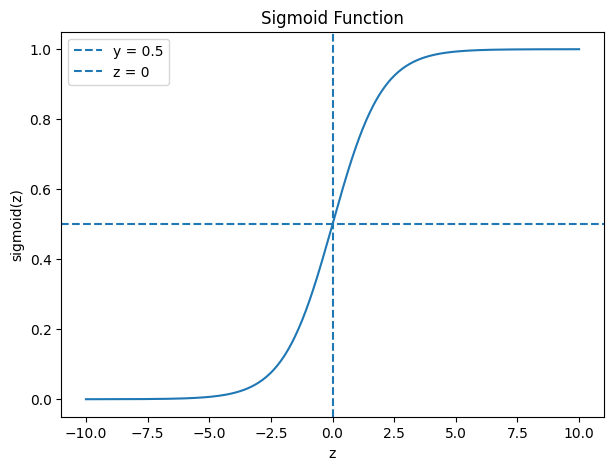

In [5]:
# -10 부터 10까지 400개의 데이터 생성
z = np.linspace(-10, 10, 400)
g = sigmoid(z)

plt.figure(figsize=(7, 5))
plt.plot(z, g)
plt.axhline(0.5, linestyle='--', label="y = 0.5")
plt.axvline(0, linestyle='--', label='z = 0')
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Function")
plt.legend()
plt.show()

## 5. Why is sigmoid useful in logistic regression?

In logistic regression, we first compute:

z = w*x + b

Then we apply the sigmoid function:

f(x) = sigmoid(z)

즉 logistic regression에서는 먼저 선형식

z = w*x + b

를 계산한 뒤 그 값을 sigmoid 함수에 넣는다.

So the model becomes:

f(x) = sigmoid(w*x + b)

이렇게 하면 출력값이 항상 0과 1사이에 된다.

Therefore, the output can be interpreted as a probability

따라서 출력값을 확률처럼 해석할 수 있다.

In [21]:
# example: logistic regression style computation
z_example = np.array([-3, -1, 0, 1, 3], dtype=float)
prob_example = sigmoid(z_example)

# 가독성을 위해 \t
print(" z\t sigmoid(z)")
for z, p in zip(z_example, prob_example):
    print(f"{z:>4}\t {p:.6f}")

 z	 sigmoid(z)
-3.0	 0.047426
-1.0	 0.268941
 0.0	 0.500000
 1.0	 0.731059
 3.0	 0.952574


## 6. Probability interpretation

If the model outputs 0.7, it does not mean y = 0.7

모델 출력이 0.7이라고 해서 y가 0.7이라는 뜻은 아니다

Instead, it means:

P(y = 1 \ x) = 0.7

즉 주어진 x에 대해 y가 1일 확률이 0.7이라는 뜻이다.

Then:

P(y = 0 | x) = 0.3

따라서 y가 0일 확률은 0.3이 된다.

In [14]:
example_output = 0.7

print("P(y = 1 | x) =", example_output)
print(f"P(y = 0 | x) =, {1 - example_output:.3f}")

P(y = 1 | x) = 0.7
P(y = 0 | x) =, 0.300


## Conclusion

The sigmoid funcion is important because  
it converts any real-valued input into a value between 0 and 1.

sigmoid 함수는 어떤 실수값이 들어와도  
0과 1사이의 값으로 바꿔준다는 점에서 중요하다.

This makes it suitable for binary classification.

이 때문에 binary classification에 적합하다.

In logistic regression:
- first compute z = w*x + b
- then apply sigmoid(z)

logistic regression에서는
- 먼저 z = w*x + b 를 계산하고
- 그 다음 sigmoid(z)를 적용한다.

So logistic regression can output probabilities.

따라서 logistic regression은 확률을 출력하는 모델이다.